# Data pipeline on the real HinGE corpus: extraction, cleaning, splits, EDA

**DATA 298A · Team 2 · Topic 23 · Team Meeting 1** · Linear 298-44 (pipeline: 298-38)

This notebook runs the team pipeline (`src/lrcs`, the same code as `scripts/run_pipeline.py`) one stage per
section, on the authors' HinGE release:

| # | Stage | Shows |
|---|---|---|
| 0 | Conversion | HinGE.pkl to CSV through a restricted unpickler |
| 1 | **Extraction** | sources, collection steps, representative samples |
| 2 | **Cleaning** | missing values, transformations, formatting, validation |
| 3 | Splits | disjoint train/dev/test, leakage gate, manifest |
| 4 | **EDA** | statistics, plots, findings |

Every number is recomputed when a cell runs; nothing is typed in. Outputs go to `out/notebook_run/` (gitignored),
so running the notebook never modifies the committed `reports/`.

In [1]:
import csv, json, subprocess, sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "lrcs").is_dir())
for entry in (ROOT / "src", ROOT / "common"):
    sys.path.insert(0, str(entry))

import pandas as pd
from IPython.display import Image, Markdown, display
from lrcs.analysis import eda
from lrcs.data import clean, ingest, leakage, splits
from lrcs.lexicon import DEFAULT_LEXICON, load_variant_groups
from lrcs.text import devanagari_fraction, normalise, sha256_file

pd.set_option("display.max_colwidth", 110)
SEED, DUP_THRESHOLD, RATIOS = 42, 0.7, {"train": 0.8, "dev": 0.1, "test": 0.1}
PKL = ROOT / "data" / "raw" / "HinGE.pkl"
CSV = ROOT / "data" / "raw" / "hinge.csv"
OUT = ROOT / "out" / "notebook_run"
HINGE_SHA256 = "e78c8f48af3eea0b141e767082189b7b619e9cbe50ad8f0b2a4863b82ebc5960"
print("repo root:", ROOT.name)

repo root: low-resource-and-code-switched-language-systems


---
## 0. Conversion: HinGE.pkl to CSV
HinGE is distributed only as a pickle, and `ingest` refuses pickles because unpickling can run code.
`scripts/convert_hinge_pkl.py` checks the file's SHA-256 and then unpickles it with an allowlist
(pandas/numpy objects only), so a malicious file is refused before anything runs.

In [2]:
if PKL.exists():
    r = subprocess.run([sys.executable, "scripts/convert_hinge_pkl.py", "data/raw/HinGE.pkl", "data/raw/hinge.csv",
                        "--expected-sha256", HINGE_SHA256], cwd=ROOT, capture_output=True, text=True)
    print(r.stdout or r.stderr)
else:
    print("HinGE.pkl not in data/raw/ -- using the existing", CSV.name)
assert CSV.exists(), "put HinGE.pkl (or hinge.csv) in data/raw/ -- see docs/datasheet.md"

input   data/raw/HinGE.pkl  sha256 e78c8f48af3eea0b141e767082189b7b619e9cbe50ad8f0b2a4863b82ebc5960
rows    1,976   human references 4,799
columns English, Hindi, Human-generated Hinglish, WAC, WAC rating1, WAC rating2, PAC, PAC rating1, PAC rating2
output  data/raw/hinge.csv  sha256 dcfaf37ca9d7528e27da7be6b0cfffafb8bbe7825fe4da45077b96236cd9c9c3



---
## 1. Data extraction

### 1a. Sources
Licences were recorded in `docs/datasheet.md` before ingestion.

| Source | Role | Licence | In this run |
|---|---|---|---|
| **HinGE** (Srivastava & Singh, 2021) | English, Hindi and human Hinglish references | research use, cite (inherits IIT Bombay CC-BY-NC) | **yes** |
| HinglishEval train/valid/test (INLG 2022) | same sentences, re-released as splits | as HinGE | **no: the splits leak (1b)** |
| MixMT 2022 Subtask-1 test | Gahoi et al. baseline reproduction | research release | baseline |
| IIT Bombay En–Hi | origin of HinGE's English and Hindi | CC-BY-NC-4.0 | indirectly |
| Samanantar | synthetic data for Model 4 | CC-BY-NC-4.0 (team decision) | 298B |
| Dakshina | Romanized ↔ Devanagari lexicons | CC BY-SA 4.0 | fertility |

### 1b. Why we re-derive our own splits
If the HinglishEval CSVs from the same Drive folder are in `data/raw/HinglishEval/`, this cell measures how
many of their dev and test sentences also occur in their train split.

In [3]:
from lrcs.text import dedup_key
he = ROOT / "data" / "raw" / "HinglishEval"
if (he / "train.csv").exists():
    keys = {n: {dedup_key(e) for e in pd.read_csv(he / f"{n}.csv").English} for n in ("train", "valid", "test")}
    display(pd.DataFrame([{"released split": a, "unique sources": len(keys[a]),
                           "also in train": len(keys[a] & keys["train"]),
                           "% leaked": round(100 * len(keys[a] & keys["train"]) / len(keys[a]), 1)}
                          for a in ("valid", "test")]))
else:
    print("HinglishEval CSVs not present; datasheet figure: 75.8% of valid sources also occur in train")

,released split,unique sources,also in train,% leaked
0,valid,376,285,75.8
1,test,707,552,78.1


### 1c. Collection steps
1. Fingerprint the file: path, timestamps, bytes, SHA-256
2. Detect the columns by name (English, Hindi, Human-generated Hinglish)
3. Parse each source's list of human references and expand it to **one record per reference**
4. Count what was actually read, without copying the paper's numbers (the paper says 4,803; the file has 4,799)

In [4]:
lexicon = load_variant_groups(DEFAULT_LEXICON)
records, prov = ingest.ingest_file(CSV)
ingest.print_provenance(prov)

  source            hinge
  path              data/raw/hinge.csv
  file mtime (UTC)  2026-10-08T04:36:13+00:00   <- when the file was retrieved/written
  ingested at (UTC) 2026-10-08T04:36:14+00:00
  bytes             1,591,630
  sha256            dcfaf37ca9d7528e27da7be6b0cfffafb8bbe7825fe4da45077b96236cd9c9c3
  columns           english=English, hindi=Hindi, hinglish=Human-generated Hinglish (from header)
  rows in file      1,976   <- measured
  records           4,799   <- one per Hinglish reference


### 1d. Representative samples
One source as released (a row of the CSV), and the records it becomes after expansion.

In [5]:
raw = pd.read_csv(CSV)
raw.iloc[[228]].T

,228
English,"very small change in time, we have a roughly constant"
Hindi,"बहुत छोटे परिवर्तन के समय में, हम एक मोटे तौर पर निरंतर है"
Human-generated Hinglish,"['Bahut chhota change time me, hum roughly constant hain', 'Bahut small change samay me, hum ek mote taur ..."
WAC,"bahut small change ke time men , ham ek mote taur par constant hai"
WAC rating1,8
WAC rating2,7
PAC,"bahut chhote change in time men, ham ek roughly taur par nirntar hai"
PAC rating1,10
PAC rating2,8


In [6]:
src = normalise(raw.loc[228, "English"])
pd.DataFrame([r for r in records if r["english"] == src])[["english", "hindi", "hinglish"]]

,english,hindi,hinglish
0,"very small change in time, we have a roughly constant","बहुत छोटे परिवर्तन के समय में, हम एक मोटे तौर पर निरंतर है","Bahut chhota change time me, hum roughly constant hain"
1,"very small change in time, we have a roughly constant","बहुत छोटे परिवर्तन के समय में, हम एक मोटे तौर पर निरंतर है","Bahut small change samay me, hum ek mote taur par constant hain"
2,"very small change in time, we have a roughly constant","बहुत छोटे परिवर्तन के समय में, हम एक मोटे तौर पर निरंतर है","Very small change samay me, we have a constant ek mote taur par"
3,"very small change in time, we have a roughly constant","बहुत छोटे परिवर्तन के समय में, हम एक मोटे तौर पर निरंतर है","Very small parivartan ke time me, hum ek mote taur par constant hain"


In [7]:
pd.DataFrame(records).sample(5, random_state=SEED)[["english", "hinglish"]]

,english,hinglish
3826,"Unto this, then, summon (O Muhammad). And be thou upright as thou art commanded, and follow not their lust...","Unto this, then, summon (O Muhammad). And be thou upright as thou art commanded, and follow not their lust..."
491,"All right, this is another one that should be cut and pasted.","Sab right hai, yeh ek aur ek cut aur paste kiya jaana chahiye."
3747,Aryans did not make any statues or temples for deities.,Aryan devtao ki koi statues or temples did not make.
3741,"Now, what stands in the way of this?","Now, In the way of this kya aavrodh he?"
287,I 'll try my best and see if I can be of any help.,"Tumhe dekhkar mujhe bahut dukh ho rha hai, toh I’ll try my best ki tum logo ki jaan bach jaaye."


---
## 2. Data cleaning

### 2a. Missing values (as released)

In [8]:
missing = pd.DataFrame({"empty cells": raw.isna().sum() + (raw.astype(str).apply(lambda c: c.str.strip()) == "").sum()})
missing["share"] = (missing["empty cells"] / len(raw)).map("{:.2%}".format)
missing

,empty cells,share
English,0,0.00%
Hindi,0,0.00%
Human-generated Hinglish,0,0.00%
WAC,0,0.00%
WAC rating1,0,0.00%
WAC rating2,0,0.00%
PAC,0,0.00%
PAC rating1,0,0.00%
PAC rating2,0,0.00%


### 2b. Transformations and formatting
- **Formatting:** the Hinglish column holds a Python list per source; it is parsed safely (`ast.literal_eval`) and expanded to one record per reference.
- **Transformations:** every field is Unicode-normalised (NFC) and whitespace is collapsed, once, at ingest.
- **Deliberately not done:** Romanized spelling is never normalised (`nahi`/`nhi`/`nahin` stay as written), because
  spelling variance is what the project measures.

In [9]:
rows = []
for col in ("English", "Hindi"):
    changed = [(v, normalise(v)) for v in raw[col].astype(str) if normalise(v) != v]
    rows.append({"column": col, "cells changed by NFC + whitespace": len(changed),
                 "example before": repr(changed[0][0][-60:]) if changed else "",
                 "example after": repr(changed[0][1][-60:]) if changed else ""})
pd.DataFrame(rows)

,column,cells changed by NFC + whitespace,example before,example after
0,English,11,'♫ from the edge of the observable universe ♫ ','♫ from the edge of the observable universe ♫'
1,Hindi,1108,"'सर्वर से कनेक्ट कर रहा है, कृपया इंतजार करें... '","'सर्वर से कनेक्ट कर रहा है, कृपया इंतजार करें...'"


In [10]:
pd.DataFrame([{"rows in file": prov["rows_in_file"], "records after expansion": prov["records"],
               "mean references per source": round(prov["records"] / prov["rows_in_file"], 2)}])

,rows in file,records after expansion,mean references per source
0,1976,4799,2.43


### 2c. Six filters, each removal charged to the first filter that rejects it

In [11]:
kept, attrition = clean.clean(records, lexicon=lexicon)
clean.print_attrition(attrition)

  filter                 in  removed     out     % rm
  ---------------------------------------------------
  missing_field       4,799        0   4,799    0.00%
  not_romanized       4,799       25   4,774    0.52%
  untranslated        4,774        0   4,774    0.00%
  length_bounds       4,774       87   4,687    1.82%
  length_ratio        4,687       11   4,676    0.23%
  exact_duplicate     4,676        2   4,674    0.04%
  ---------------------------------------------------
  ingested 4,799 -> kept 4,674 (125 removed)


In [12]:
by_id = {r["id"]: r for r in records}
pd.DataFrame([{"filter": row["filter"], "removed": row["removed"], "example removed Hinglish": by_id[i]["hinglish"][:90]}
              for row in attrition["table"] for i in row["examples"][:1]])

,filter,removed,example removed Hinglish
0,not_romanized,25,चाएँगें ताकि तू अपने बाद वालों के लिए इबरत का (बाइस) हो और इसमें तो शक़ नहीं कि तेरे लोग ह
1,length_bounds,87,CMMS:
2,length_ratio,11,Bhi us story ko sun raha tha.
3,exact_duplicate,2,Kya twarit compositing should be enabled


### 2d. Validation
Checks recomputed here on the cleaned records. Every one must pass before the data can be split.

In [13]:
removed_sum = sum(r["removed"] for r in attrition["table"])
checks = {
    "no empty English or Hinglish": all(r["english"] and r["hinglish"] for r in kept),
    "Hinglish is Romanized (Devanagari share <= 0.2)": all(devanagari_fraction(r["hinglish"]) <= 0.2 for r in kept),
    "attrition adds up (ingested = kept + removed)": attrition["ingested"] == attrition["kept"] + removed_sum,
    "no duplicate (English, Hinglish) pairs": len({(dedup_key(r["english"]), dedup_key(r["hinglish"])) for r in kept}) == len(kept),
    "every kept record carries language tags": all(len(r["tags"]) > 0 for r in kept),
    "record ids unique": len({r["id"] for r in kept}) == len(kept),
}
pd.DataFrame({"check": list(checks), "result": ["PASS" if v else "FAIL" for v in checks.values()]})

,check,result
0,no empty English or Hinglish,PASS
1,Hinglish is Romanized (Devanagari share <= 0.2),PASS
2,attrition adds up (ingested = kept + removed),PASS
3,"no duplicate (English, Hinglish) pairs",PASS
4,every kept record carries language tags,PASS
5,record ids unique,PASS


In [14]:
assert all(checks.values()), "validation failed -- do not split this data"

---
## 3. Splits and leakage gate
Near-duplicate English sources (character 4-gram Jaccard ≥ 0.7) are grouped, whole groups go to one split
(80/10/10, seed 42), and the leakage gate re-checks every source across splits. If the gate fails, nothing is written.

In [15]:
derived, info = splits.derive_splits(kept, RATIOS, DUP_THRESHOLD, SEED, max_group_frac=0.05)
splits.print_split_summary(derived, info)
report = leakage.check(derived, DUP_THRESHOLD, seed=SEED)
leakage.print_report(report)
assert report["passed"]

  sources 1,938 -> 1,937 groups (1 merged as near-duplicates, 1 verified pairs; largest group 8)
  train   3,738 records
  dev       468 records
  test      468 records


  leakage gate PASSED: 1,938 sources checked at Jaccard >= 0.7 -- 0 exact, 0 near-duplicate overlaps


In [16]:
params = {"seed": SEED, "dup_threshold": DUP_THRESHOLD, "ratios": RATIOS, "max_group_frac": 0.05,
          "shingle": splits.SHINGLE, "num_perm": splits.NUM_PERM, "rows_per_band": splits.ROWS_PER_BAND,
          "clean": attrition["params"]}
manifest_path, manifest = splits.write_splits(derived, info, prov, params, OUT / "processed", OUT / "manifests")
committed = json.loads((ROOT / "data" / "processed" / "manifests" / "hinge_split_manifest.json").read_text())
pd.DataFrame({name: {"records": len(derived[name]),
                     "sha256 (this run)": manifest["splits"][name]["sha256"][:16],
                     "sha256 (committed)": committed["splits"][name]["sha256"][:16]} for name in RATIOS}).T

,records,sha256 (this run),sha256 (committed)
train,3738,82c045f21bb5d55e,82c045f21bb5d55e
dev,468,db0b17cca1443108,db0b17cca1443108
test,468,6ac5d302fe34dd66,6ac5d302fe34dd66


Identical hashes in the last two columns mean this run reproduced the committed splits byte for byte.

---
## 4. Exploratory data analysis

In [17]:
stats, series = eda.compute_statistics(derived, prov, attrition, info, report, lexicon, params,
                                       manifest_path=manifest_path)
figures = eda.write_figures(stats, series, OUT / "figures")
eda.print_statistics(stats)

  records           4,674 across train 3,738, dev 468, test 468
  refs per source   2.41 mean
  length (words)    English mean 15.2 / median 12.0   Hinglish mean 15.9 / median 12.0
  vocabulary        Hinglish 13,204 types / 74,165 tokens (TTR 0.178)
  tagger coverage   68.2% of word tokens resolved to lang1/lang2
  CMI               25.34 mean, 86.1% of sentences mixed
  SPF               0.2398   M-index 0.6930
  spelling variance 68/72 lexicon groups seen, 28 with 2+ spellings, 12.9% of their occurrences non-canonical


### 4a. Key statistics

In [18]:
L, V, CM, SV = stats["lengths_words"], stats["vocabulary"], stats["code_mixing"], stats["spelling_variance"]
pd.DataFrame([
    ("records after cleaning", f"{attrition['kept']:,}"),
    ("train / dev / test records", " / ".join(f"{len(derived[s]):,}" for s in RATIOS)),
    ("English words: mean / median / p95", f"{L['english']['mean']:.1f} / {L['english']['median']:.0f} / {L['english']['p95']}"),
    ("Hinglish words: mean / median / p95", f"{L['hinglish']['mean']:.1f} / {L['hinglish']['median']:.0f} / {L['hinglish']['p95']}"),
    ("Hinglish/English length ratio (mean)", f"{L['hinglish_to_english_ratio_mean']:.2f}"),
    ("Hinglish vocabulary: types / tokens (TTR)", f"{V['hinglish_types']:,} / {V['hinglish_tokens']:,} ({V['hinglish_type_token_ratio']})"),
    ("references per source (mean)", f"{stats['references_per_source']['mean']:.2f}"),
    ("tagger coverage", f"{CM['tagger_coverage']:.1%}"),
    ("CMI mean / sentences mixed", f"{CM['cmi_mean_all']:.1f} / {CM['frac_sentences_mixed']:.1%}"),
    ("switch-point fraction / M-index", f"{CM['switch_point_fraction']:.3f} / {CM['m_index']:.3f}"),
    ("lexicon groups seen / with 2+ spellings", f"{SV['groups_observed']} / {SV['groups_with_2plus_forms']}"),
    ("non-canonical spellings among lexicon words", f"{SV['non_canonical_share_overall']:.1%}"),
], columns=["statistic", "value"])

,statistic,value
0,records after cleaning,"4,674"
1,train / dev / test records,"3,738 / 468 / 468"
2,English words: mean / median / p95,15.2 / 12 / 37
3,Hinglish words: mean / median / p95,15.9 / 12 / 39
4,Hinglish/English length ratio (mean),1.06
5,Hinglish vocabulary: types / tokens (TTR),"13,204 / 74,165 (0.178)"
6,references per source (mean),2.41
7,tagger coverage,68.2%
8,CMI mean / sentences mixed,25.3 / 86.1%
9,switch-point fraction / M-index,0.240 / 0.693


In [19]:
pd.DataFrame(stats["references_per_source"]["distribution"], index=["sources"])

,1,2,3,4,5,6,7,8
sources,26,1470,166,210,37,21,5,3


### 4b. Sentence length
English and Hinglish lengths track each other closely: the pairs are well aligned.

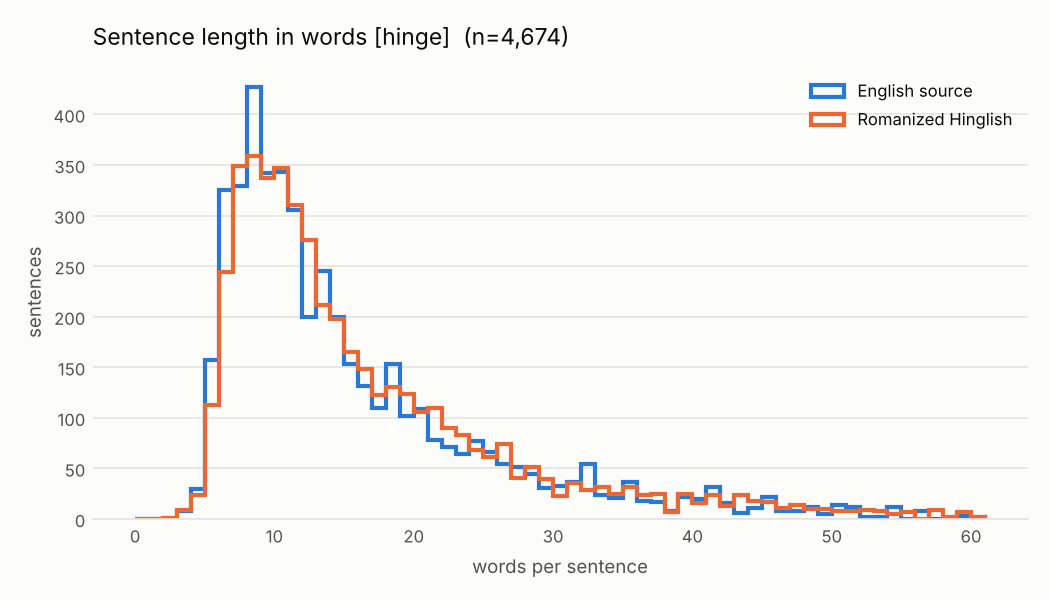

In [20]:
display(Image(filename=str(ROOT / figures["lengths"])))

### 4c. How code-mixed is each sentence?
Code-Mixing Index (0 = one language, 50 = an even mix).

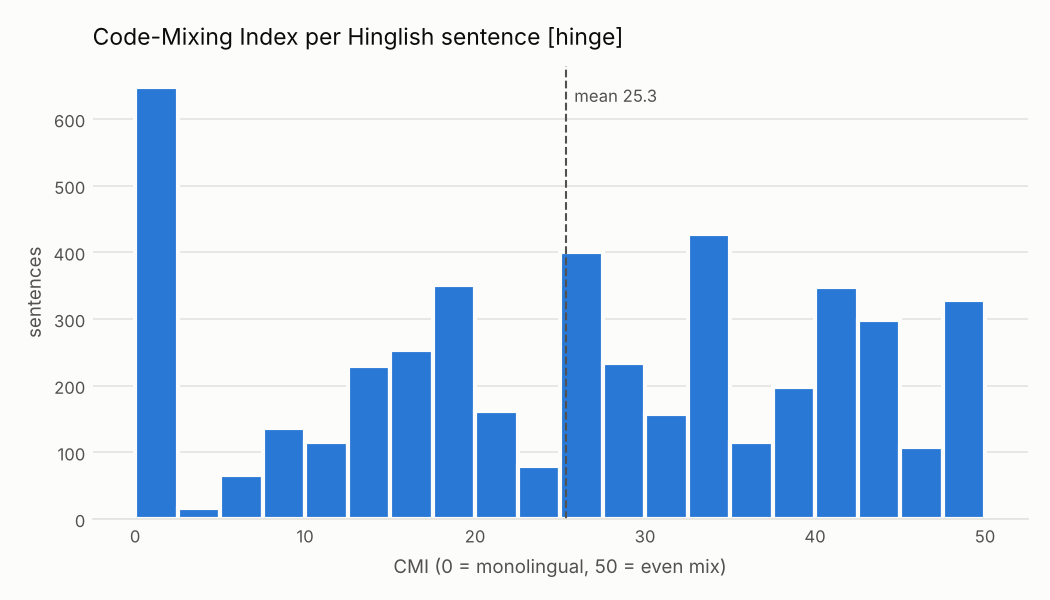

In [21]:
display(Image(filename=str(ROOT / figures["cmi"])))

### 4d. How often does the language switch?
The corpus SPF is the target for SPF-matched synthetic data in Model 4.

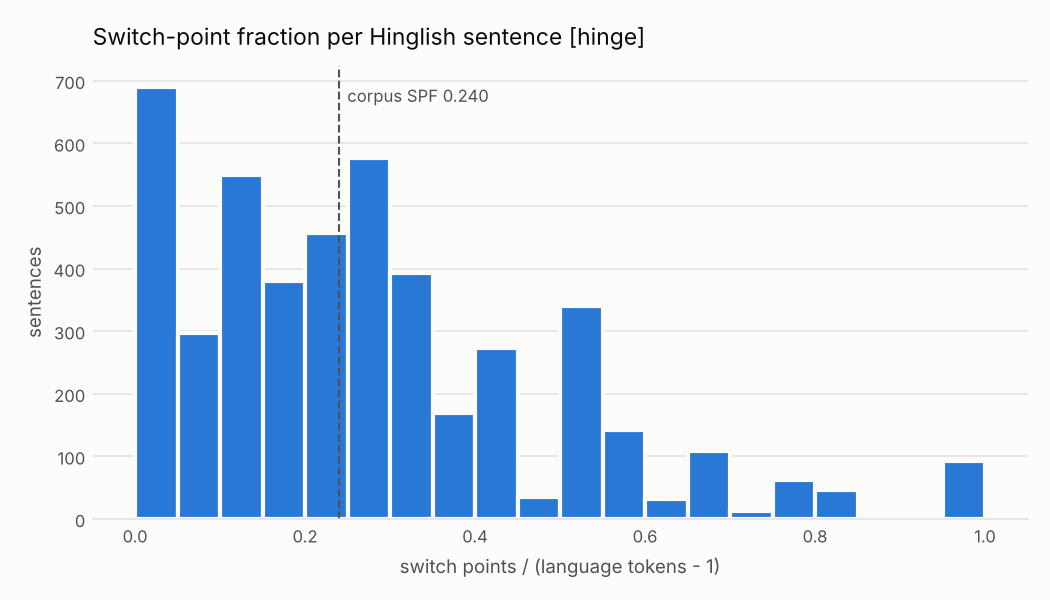

In [22]:
display(Image(filename=str(ROOT / figures["spf"])))

### 4e. Is spelling unstable? (the project's hypothesis)
Orange = non-canonical spellings of the same word.

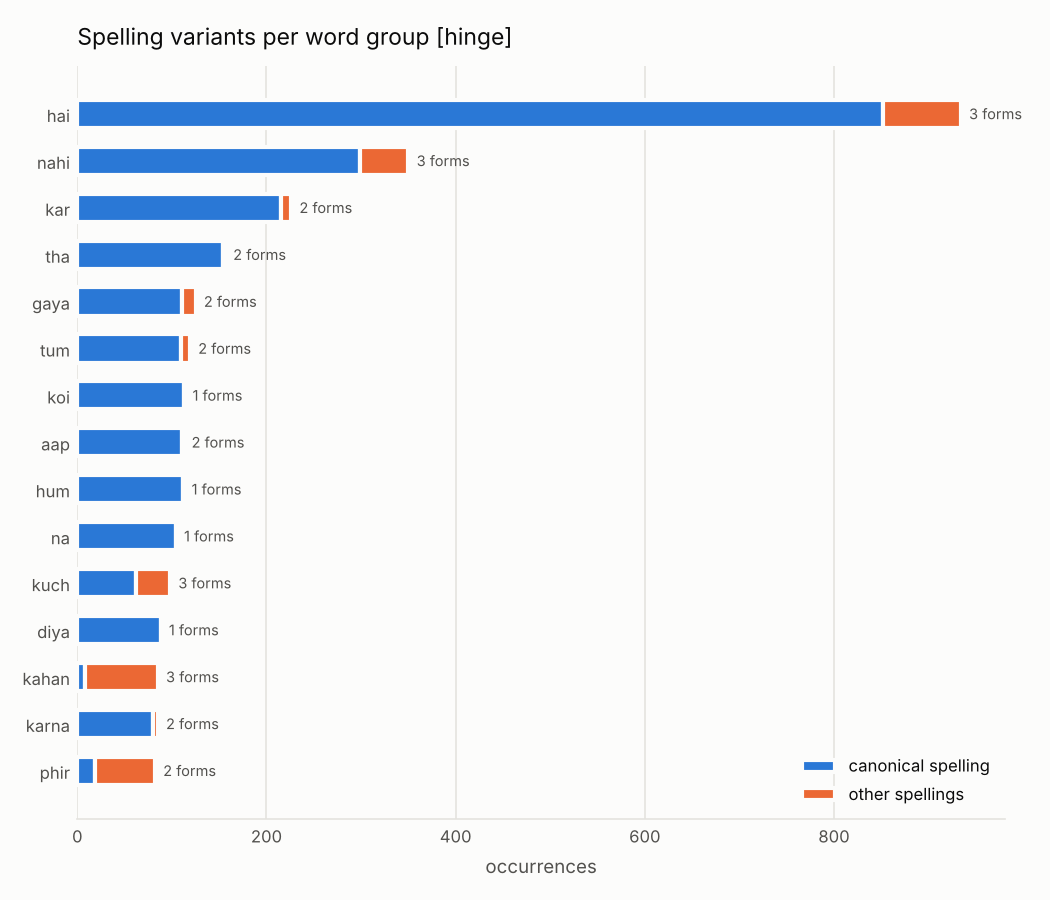

In [23]:
display(Image(filename=str(ROOT / figures["variants"])))

### 4f. Spelling variants in detail

In [24]:
pd.DataFrame([{"word": g["group"], "occurrences": g["occurrences"], "spellings": g["forms"],
               "non-canonical share": f"{g['non_canonical_share']:.1%}"} for g in SV["top_groups"][:12]])

,word,occurrences,spellings,non-canonical share
0,hai,934,"{'hai': 852, 'h': 50, 'hain': 32}",8.8%
1,nahi,350,"{'nahi': 299, 'nhi': 38, 'nai': 13}",14.6%
2,kar,226,"{'kar': 215, 'kr': 11}",4.9%
3,tha,156,"{'tha': 154, 'th': 2}",1.3%
4,gaya,125,"{'gaya': 111, 'gya': 14}",11.2%
5,tum,119,"{'tum': 110, 'tu': 9}",7.6%
6,koi,113,{'koi': 113},0.0%
7,aap,112,"{'aap': 111, 'ap': 1}",0.9%
8,hum,112,{'hum': 112},0.0%
9,na,104,{'na': 104},0.0%


### 4g. Important findings (worded from the numbers above)

In [25]:
mixed = CM["frac_sentences_mixed"]; nc = SV["non_canonical_share_overall"]
findings = [
    f"**Extraction is faithful:** {prov['rows_in_file']:,} source rows and {prov['records']:,} human references measured from the file "
    f"(the paper reports 4,803, so the four-reference gap is recorded rather than hidden).",
    f"**Cleaning is light and fully accounted for:** {attrition['kept']:,} of {attrition['ingested']:,} records kept "
    f"({attrition['kept'] / attrition['ingested']:.1%}); the largest filter is "
    f"`{max(attrition['table'], key=lambda r: r['removed'])['filter']}`.",
    f"**The splits are clean:** leakage gate passed over {report['sources_checked']:,} sources with "
    f"{report['exact_overlaps']} exact and {report['near_overlaps']} near-duplicate overlaps. The released HinglishEval splits do leak.",
    f"**The references are {'genuinely' if mixed >= 0.5 else 'only partly'} code-mixed:** {mixed:.0%} of sentences mix both languages, "
    f"mean CMI {CM['cmi_mean_all']:.1f}, switch-point fraction {CM['switch_point_fraction']:.3f} "
    f"(rule-based tagger, {CM['tagger_coverage']:.0%} coverage).",
    f"**Spelling varies, {'clearly' if nc >= 0.10 else 'but modestly'}:** {SV['groups_with_2plus_forms']} of {SV['groups_observed']} "
    f"common words appear in two or more spellings, and {nc:.1%} of their occurrences are non-canonical "
    f"(for example nahi / nhi / nai). HinGE's English comes from formal IIT Bombay text, so casual social-media "
    f"Hinglish (PHINC) is the next test of the hypothesis.",
]
display(Markdown("\n".join(f"{i}. {t}" for i, t in enumerate(findings, 1))))

1. **Extraction is faithful:** 1,976 source rows and 4,799 human references measured from the file (the paper reports 4,803, so the four-reference gap is recorded rather than hidden).
2. **Cleaning is light and fully accounted for:** 4,674 of 4,799 records kept (97.4%); the largest filter is `length_bounds`.
3. **The splits are clean:** leakage gate passed over 1,938 sources with 0 exact and 0 near-duplicate overlaps. The released HinglishEval splits do leak.
4. **The references are genuinely code-mixed:** 86% of sentences mix both languages, mean CMI 25.3, switch-point fraction 0.240 (rule-based tagger, 68% coverage).
5. **Spelling varies, clearly:** 28 of 68 common words appear in two or more spellings, and 12.9% of their occurrences are non-canonical (for example nahi / nhi / nai). HinGE's English comes from formal IIT Bombay text, so casual social-media Hinglish (PHINC) is the next test of the hypothesis.

---
## 5. Reproducibility

In [26]:
r = subprocess.run([sys.executable, "-m", "pytest", "-q", "--color=no", str(ROOT / "tests")],
                   cwd=ROOT, capture_output=True, text=True)
print(r.stdout.strip().splitlines()[-1])

27 passed in 5.54s


- The same result from the command line: `python scripts/run_pipeline.py --input data/raw/hinge.csv --seed 42`
- Committed evidence: `reports/data_statistics.json`, `reports/figures/`, `data/processed/manifests/hinge_split_manifest.json`, `runs/*data-pipeline*.json`
- Never committed: `data/raw/`, the split TSVs and `out/` (all gitignored)